In [1]:
import pandas as pd
import os

def load_wine_data():
    base_path = os.path.dirname(__file__) 

    red_path = os.path.join(base_path, "winequality-red.csv")
    white_path = os.path.join(base_path, "winequality-white.csv")

    red = pd.read_csv(red_path, sep=';')
    white = pd.read_csv(white_path, sep=';')

    red['type'] = 'red'
    white['type'] = 'white'

    df = pd.concat([red, white], ignore_index=True)
    return df

In [2]:
from load_data import load_wine_data

df = load_wine_data()

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())

print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (6497, 13)

Data Types:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                     object
dtype: object

Summary Statistics:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    6497.000000       6497.000000  6497.000000     6497.000000   
mean        7.215307          0.339666     0.318633        5.443235   
std         1.296434          0.164636     0.145318        4.757804   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.250000        1.800000   
50%         7.000000          0.290000     0.310000        3.000000   
75%         7.70000

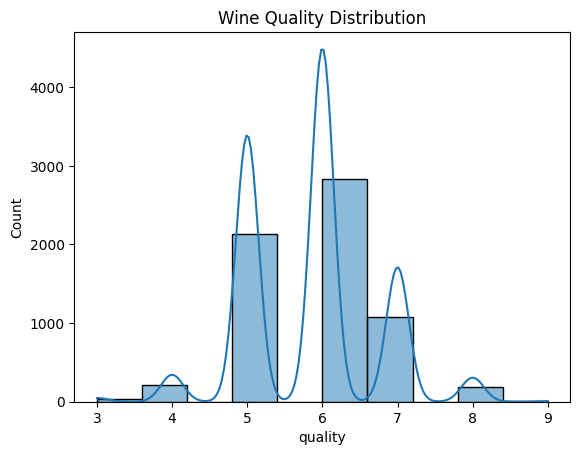

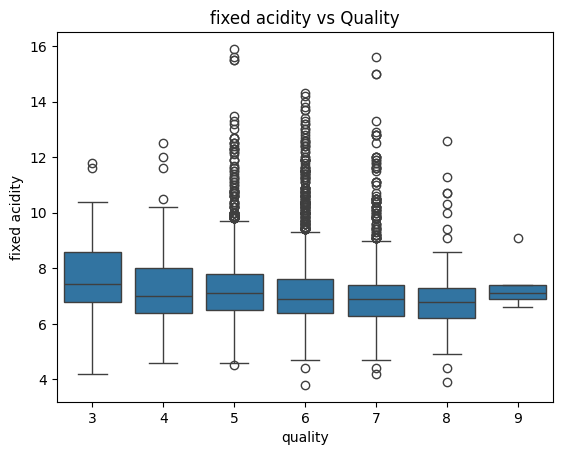

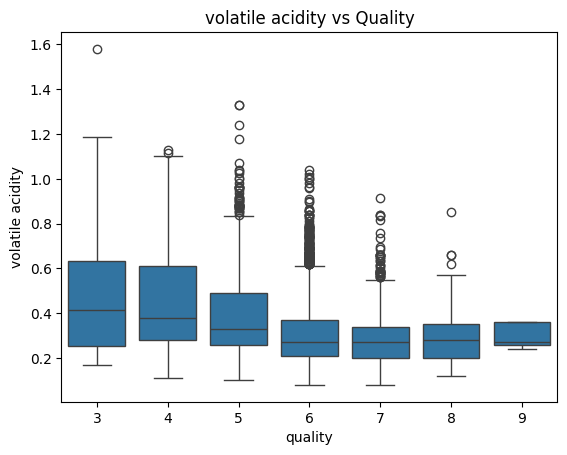

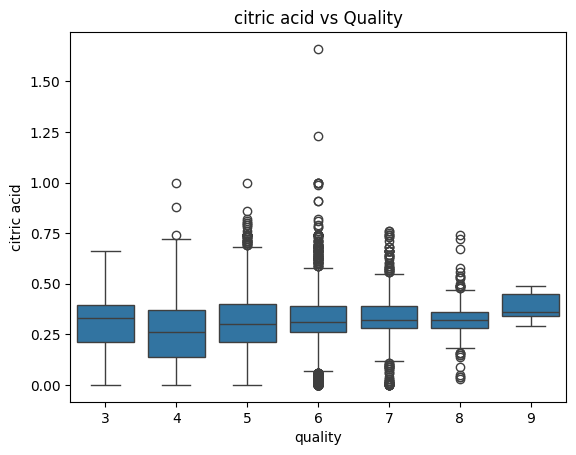

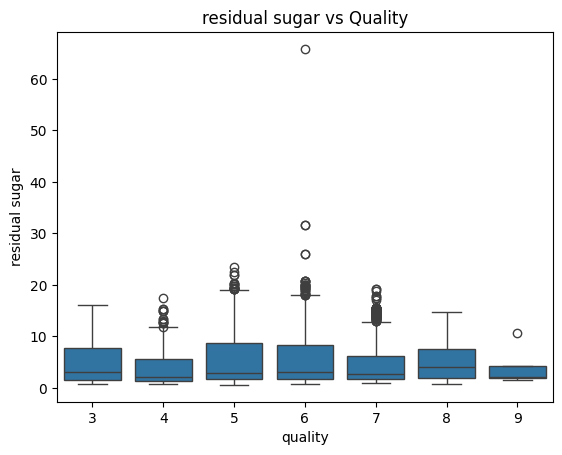

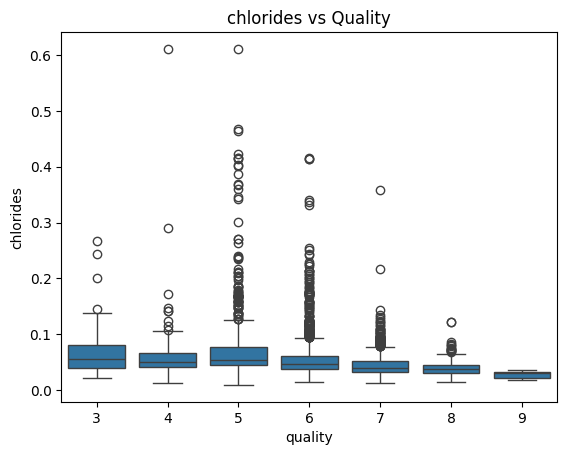

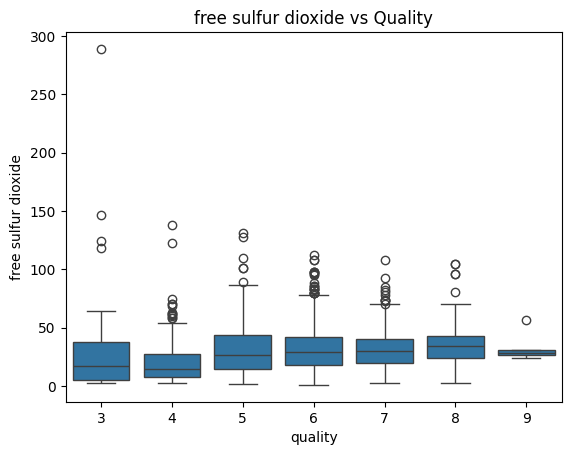

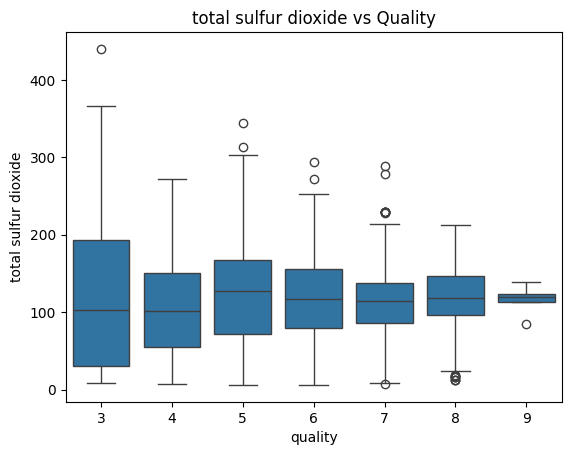

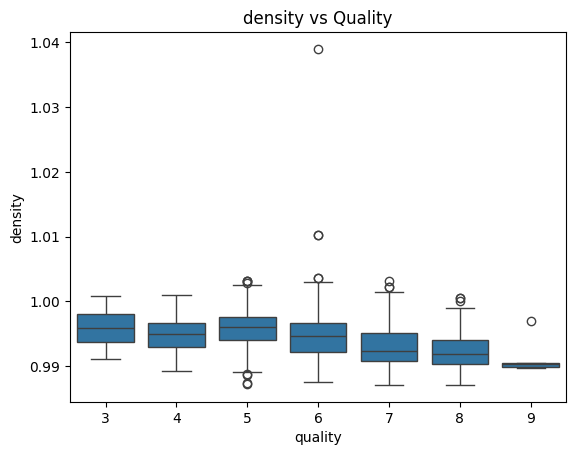

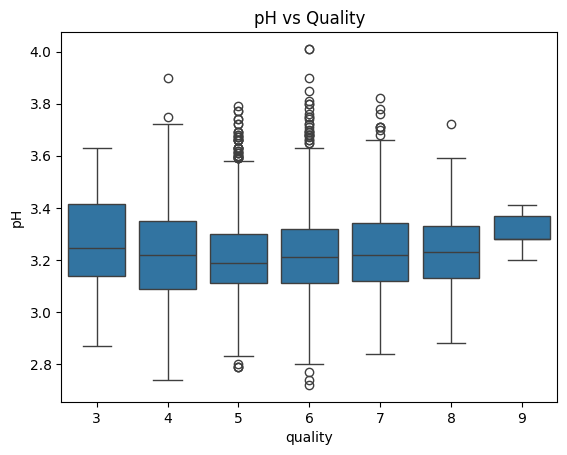

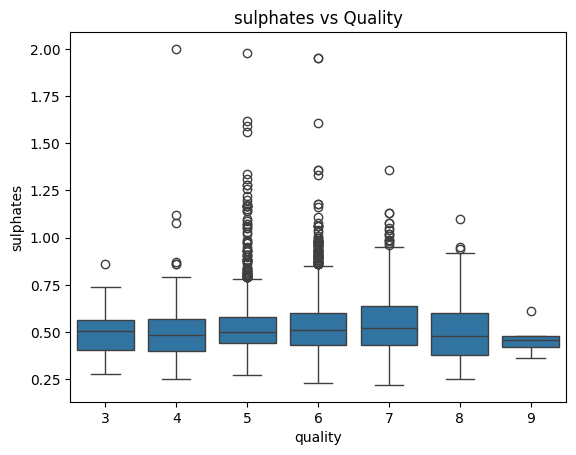

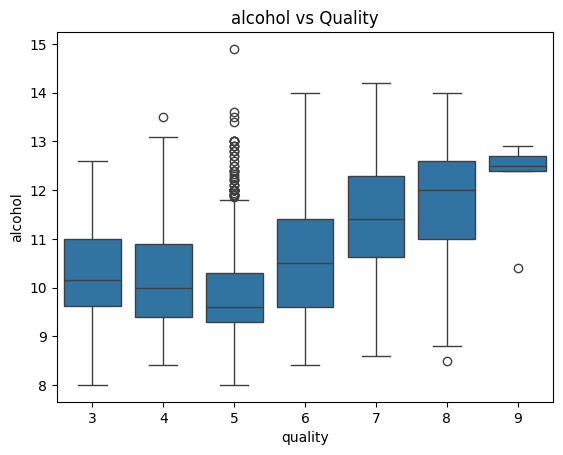

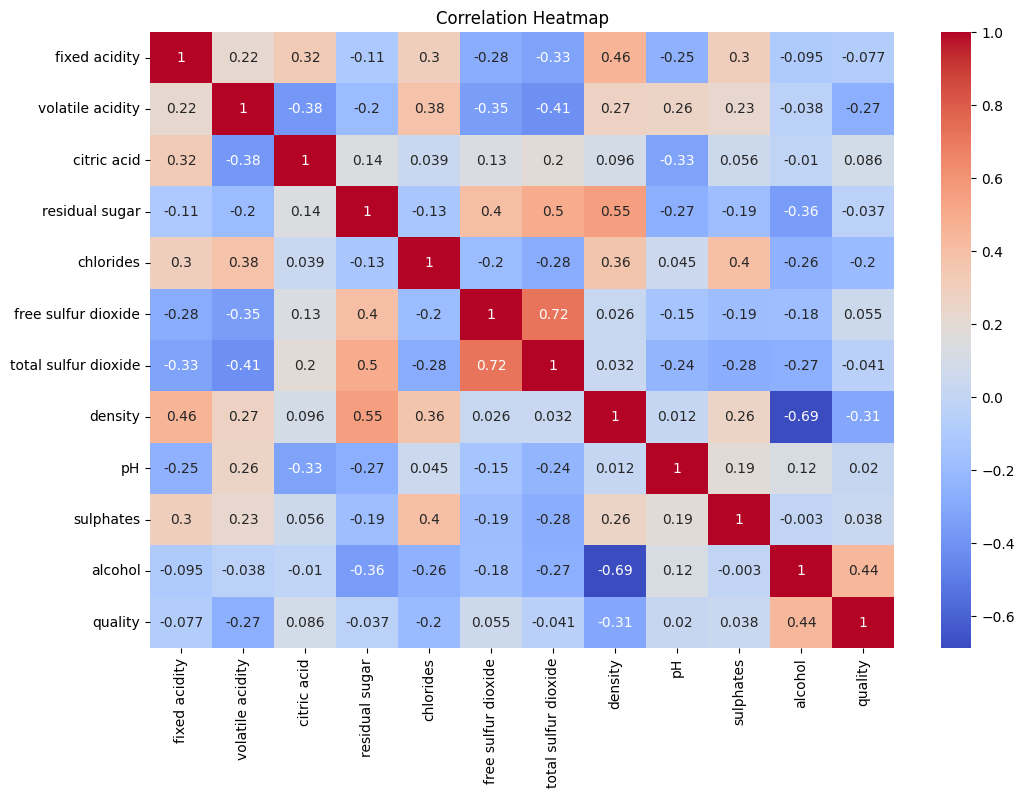

Top Positive Correlations:
 quality                1.000000
alcohol                0.444319
citric acid            0.085532
free sulfur dioxide    0.055463
sulphates              0.038485
Name: quality, dtype: float64

Top Negative Correlations:
 total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [3]:
from load_data import load_wine_data
import matplotlib.pyplot as plt
import seaborn as sns

df = load_wine_data()

# Histogram
sns.histplot(df['quality'], bins=10, kde=True)
plt.title("Wine Quality Distribution")
plt.show()

# Boxplots
features = df.columns[:-2]

for col in features:
    plt.figure()
    sns.boxplot(x=df['quality'], y=df[col])
    plt.title(f"{col} vs Quality")
    plt.show()

# Heatmap
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Correlation insights
quality_corr = corr['quality'].sort_values(ascending=False)

print("Top Positive Correlations:\n", quality_corr.head())
print("\nTop Negative Correlations:\n", quality_corr.tail())

In [4]:
from load_data import load_wine_data
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

df = load_wine_data()

# Convert to classification
def quality_label(q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2

df['quality_label'] = df['quality'].apply(quality_label)

# Features & Target
X = df.drop(['quality', 'quality_label', 'type'], axis=1)
y = df['quality_label']

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Save for reuse
pd.DataFrame(X_train).to_csv("X_train.csv", index=False)
pd.DataFrame(X_test).to_csv("X_test.csv", index=False)
pd.DataFrame(y_train).to_csv("y_train.csv", index=False)
pd.DataFrame(y_test).to_csv("y_test.csv", index=False)

print("Preprocessing done & files saved.")

Preprocessing done & files saved.


In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load data
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Save results
pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"]).to_csv("results.csv", index=False)

C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Logistic Regression
Accuracy: 0.7907692307692308
Precision: 0.7403202669721571
Recall: 0.7907692307692308
F1 Score: 0.7495695796327612
Confusion Matrix:
 [[  0  47   2]
 [  0 955  44]
 [  0 179  73]]

KNN
Accuracy: 0.7946153846153846
Precision: 0.7719346844172613
Recall: 0.7946153846153846
F1 Score: 0.7756612115222324
Confusion Matrix:
 [[  4  43   2]
 [  5 914  80]
 [  0 137 115]]

Decision Tree
Accuracy: 0.796923076923077
Precision: 0.7976367268048814
Recall: 0.796923076923077
F1 Score: 0.7970735664540914
Confusion Matrix:
 [[ 13  31   5]
 [ 28 865 106]
 [  1  93 158]]

Random Forest
Accuracy: 0.8569230769230769
Precision: 0.8523947885598021
Recall: 0.8569230769230769
F1 Score: 0.8388100827695659
Confusion Matrix:
 [[  5  44   0]
 [  1 961  37]
 [  0 104 148]]


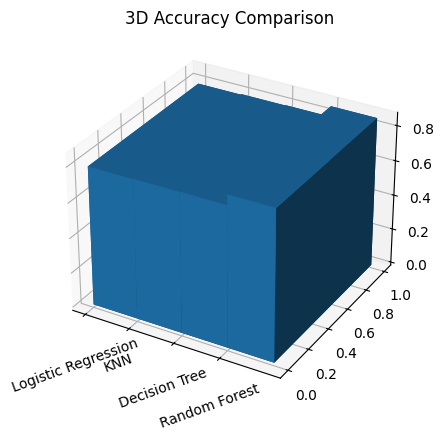

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

df = pd.read_csv("results.csv")

models = df['Model']
accuracy = df['Accuracy']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x_pos = np.arange(len(models))
y_pos = np.zeros(len(models))
z_pos = np.zeros(len(models))

dx = np.ones(len(models))
dy = np.ones(len(models))
dz = accuracy

ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz)

ax.set_xticks(x_pos)
ax.set_xticklabels(models, rotation=20)
ax.set_title("3D Accuracy Comparison")

plt.show()